# Imports

In [1]:
import pickle
from collections import Counter
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from beatmap_classifier.classifier.utils_training import (get_data, get_additional_features, pad_sequences_pt,
                                                          train_and_evaluate, plot_training_history, load_pytorch_models)
from beatmap_classifier.classifier.augment_faster import augment_dataset, extract_movement_features_from_X

# Model Testing

Go run test_model.py

# Initializing some Data

In [2]:
TOURNAMENT_MODS = {
    "nm1": "NM",
    "nm2": "NM",
    "nm3": "NM",
    "nm4": "NM",
    "nm5": "NM",
    "nm6": "NM",
    "hd1": "HD",
    "hd2": "HD",
    "hd3": "HD",
    "hr1": "HR",
    "hr2": "HR",
    "hr3": "HR",
    "dt1": "DT",
    "dt2_and_dt3": "DT",
    "dt4": "DT",
    "tiebreaker": "NM",
}

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

db_path = 'beatmaps.db'

X, y, beatmap_ids = get_data(db_path)
raw_additional_features, normalized_additional_features = get_additional_features(db_path, y, beatmap_ids)

Max Vector Length: 500.0
Max Time Diff: 86087.0
Tournament-labeled beatmaps: 3919
Max Vector Count: 6309
Original beatmaps: 3919


In [4]:
# Get the mod associated with each tournament label
mods_flattened = [
    TOURNAMENT_MODS[label]
    if TOURNAMENT_MODS[label]
    else "NM"
    for label in y
]

raw_additional_features_array = np.array([
    raw_additional_features[(beatmap_id, mod)]
    for beatmap_id, mod in zip(beatmap_ids, mods_flattened)
])

normalized_additional_features_array = np.array([
    normalized_additional_features[(beatmap_id, mod)]
    for beatmap_id, mod in zip(beatmap_ids, mods_flattened)
])

In [5]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    beatmap_ids_train,
    beatmap_ids_test,
) = train_test_split(
    X,
    y,
    beatmap_ids,
    test_size=0.2,
    random_state=42,
)

print(f"Final train size: {len(X_train)}")
print(f"Final test size:  {len(X_test)}")

Final train size: 3135
Final test size:  784


In [6]:
# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(y)

with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

y_train_numerical = label_encoder.transform(y_train)
y_test_numerical = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

y_train_numerical = torch.tensor(y_train_numerical, dtype=torch.long)
y_test_numerical = torch.tensor(y_test_numerical, dtype=torch.long)

# Pad sequences
sequence_lengths = np.array([len(seq) for seq in X])
max_length = int(np.percentile(sequence_lengths, 99))
max_length = 2 ** int(np.ceil(np.log2(max_length)))
max_length = min(max_length, 4096)

print(f"Using max sequence length: {max_length}")

X_train = pad_sequences_pt(
    X_train,
    maxlen=max_length,
    dtype=torch.float32
)

X_test = pad_sequences_pt(
    X_test,
    maxlen=max_length,
    dtype=torch.float32
)

print("Before metadata:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

Using max sequence length: 4096
Before metadata:
X_train: torch.Size([3135, 4096, 8])
X_test:  torch.Size([784, 4096, 8])


In [7]:
class_counts = Counter(y_train_numerical.numpy())

for cls, count in sorted(class_counts.items()):
    print(f"Class {cls}: {count}")

print(dict(enumerate(label_encoder.classes_)))

Class 0: 701
Class 1: 698
Class 2: 724
Class 3: 611
Class 4: 401
{0: np.str_('nm1'), 1: np.str_('nm2'), 2: np.str_('nm3'), 3: np.str_('nm4'), 4: np.str_('nm5')}


In [8]:
# 1. Extract geometric summary vectors for each row in X_train and X_test
movement_features_train = np.array(
    [extract_movement_features_from_X(X_train[i]) for i in range(len(X_train))],
    dtype=np.float32,
)

movement_features_test = np.array(
    [extract_movement_features_from_X(X_test[i]) for i in range(len(X_test))],
    dtype=np.float32,
)

# TODO: NOTICE THAT WE SWITCH FROM NORMALIZED TO RAW ADDITIONAL FEATURES
#       BECAUSE XGBOOST DOESN'T NEED SCALING

# 2. Extract SQLite metadata features corresponding to train/test IDs
sql_features_train = np.array(
    [
        raw_additional_features[(b_id, "NM")]
        for b_id in beatmap_ids_train
    ],
    dtype=np.float32,
)

sql_features_test = np.array(
    [raw_additional_features[(b_id, "NM")] for b_id in beatmap_ids_test],
    dtype=np.float32,
)

# 3. Concatenate (SQL metadata + Movement geometric summary)
X_additional_train = np.hstack(
    [sql_features_train, movement_features_train]
)
X_additional_test = np.hstack(
    [sql_features_test, movement_features_test]
)

print(f"Full meta tabular train shape: {X_additional_train.shape}")
print(f"Full meta tabular test shape:  {X_additional_test.shape}")

Full meta tabular train shape: (3135, 24)
Full meta tabular test shape:  (784, 24)


# CNN Model (SKIP TO XGBOOST IF DESIRED)

--- Training Meta Fold 1/5 ---
Original samples: 2508 -> Augmented total: 10032
Epoch 1/30 - loss: 1.1888 - acc: 0.5830 - val_loss: 0.9892 - val_acc: 0.6922
Epoch 2/30 - loss: 0.9974 - acc: 0.7094 - val_loss: 0.9070 - val_acc: 0.7321
Epoch 3/30 - loss: 0.9511 - acc: 0.7401 - val_loss: 0.8744 - val_acc: 0.7496
Epoch 4/30 - loss: 0.8951 - acc: 0.7728 - val_loss: 0.8635 - val_acc: 0.8022
Epoch 5/30 - loss: 0.8627 - acc: 0.7964 - val_loss: 0.7907 - val_acc: 0.8166
Epoch 6/30 - loss: 0.8547 - acc: 0.7938 - val_loss: 0.7498 - val_acc: 0.8421
Epoch 7/30 - loss: 0.8255 - acc: 0.8146 - val_loss: 0.7629 - val_acc: 0.8405
Epoch 8/30 - loss: 0.8010 - acc: 0.8236 - val_loss: 0.7440 - val_acc: 0.8405
Epoch 9/30 - loss: 0.7828 - acc: 0.8382 - val_loss: 0.7693 - val_acc: 0.8278
Epoch 10/30 - loss: 0.7600 - acc: 0.8534 - val_loss: 0.7084 - val_acc: 0.8612
Epoch 11/30 - loss: 0.7407 - acc: 0.8600 - val_loss: 0.7841 - val_acc: 0.8070
Epoch 12/30 - loss: 0.7333 - acc: 0.8650 - val_loss: 0.7210 - val_acc: 

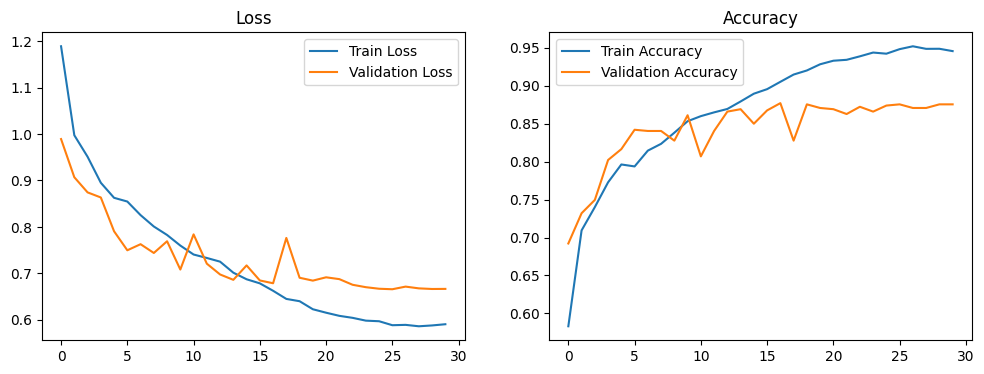

--- Training Meta Fold 2/5 ---
Original samples: 2508 -> Augmented total: 10032
Epoch 1/30 - loss: 1.2345 - acc: 0.5534 - val_loss: 0.9252 - val_acc: 0.7352
Epoch 2/30 - loss: 1.0176 - acc: 0.6908 - val_loss: 0.8663 - val_acc: 0.7847
Epoch 3/30 - loss: 0.9709 - acc: 0.7222 - val_loss: 0.8524 - val_acc: 0.7911
Epoch 4/30 - loss: 0.9109 - acc: 0.7639 - val_loss: 0.7833 - val_acc: 0.8166
Epoch 5/30 - loss: 0.8935 - acc: 0.7734 - val_loss: 0.7372 - val_acc: 0.8517
Epoch 6/30 - loss: 0.8605 - acc: 0.7988 - val_loss: 0.7574 - val_acc: 0.8325
Epoch 7/30 - loss: 0.8264 - acc: 0.8134 - val_loss: 0.7436 - val_acc: 0.8501
Epoch 8/30 - loss: 0.8074 - acc: 0.8245 - val_loss: 0.6899 - val_acc: 0.8692
Epoch 9/30 - loss: 0.7953 - acc: 0.8347 - val_loss: 0.6968 - val_acc: 0.8756
Epoch 10/30 - loss: 0.7838 - acc: 0.8364 - val_loss: 0.6866 - val_acc: 0.8676
Epoch 11/30 - loss: 0.7526 - acc: 0.8576 - val_loss: 0.6686 - val_acc: 0.8772
Epoch 12/30 - loss: 0.7422 - acc: 0.8643 - val_loss: 0.6572 - val_acc: 

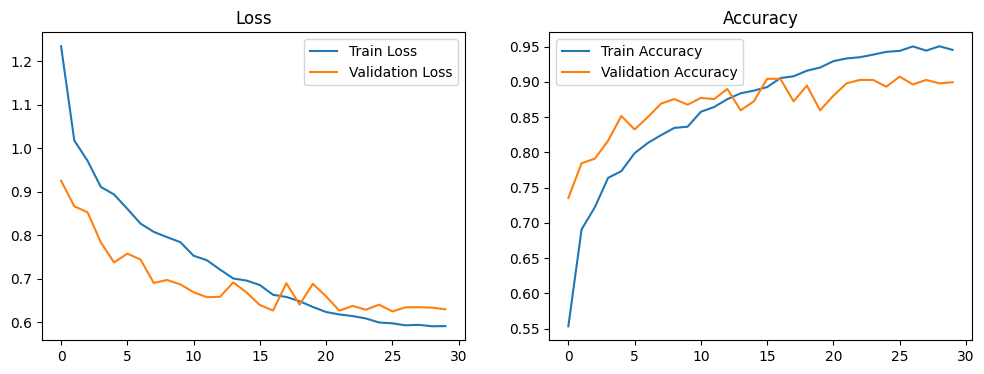

--- Training Meta Fold 3/5 ---
Original samples: 2508 -> Augmented total: 10032
Epoch 1/30 - loss: 1.1579 - acc: 0.6001 - val_loss: 0.9187 - val_acc: 0.7257
Epoch 2/30 - loss: 0.9669 - acc: 0.7249 - val_loss: 0.8101 - val_acc: 0.8166
Epoch 3/30 - loss: 0.9244 - acc: 0.7529 - val_loss: 0.9138 - val_acc: 0.7321
Epoch 4/30 - loss: 0.8805 - acc: 0.7852 - val_loss: 0.7276 - val_acc: 0.8708
Epoch 5/30 - loss: 0.8467 - acc: 0.8016 - val_loss: 0.7598 - val_acc: 0.8373
Epoch 6/30 - loss: 0.8211 - acc: 0.8184 - val_loss: 0.7457 - val_acc: 0.8278
Epoch 7/30 - loss: 0.8081 - acc: 0.8248 - val_loss: 0.7123 - val_acc: 0.8820
Epoch 8/30 - loss: 0.7799 - acc: 0.8395 - val_loss: 0.6827 - val_acc: 0.8820
Epoch 9/30 - loss: 0.7733 - acc: 0.8481 - val_loss: 0.6608 - val_acc: 0.8868
Epoch 10/30 - loss: 0.7496 - acc: 0.8568 - val_loss: 0.6476 - val_acc: 0.8995
Epoch 11/30 - loss: 0.7340 - acc: 0.8667 - val_loss: 0.6671 - val_acc: 0.8772
Epoch 12/30 - loss: 0.7229 - acc: 0.8727 - val_loss: 0.7348 - val_acc: 

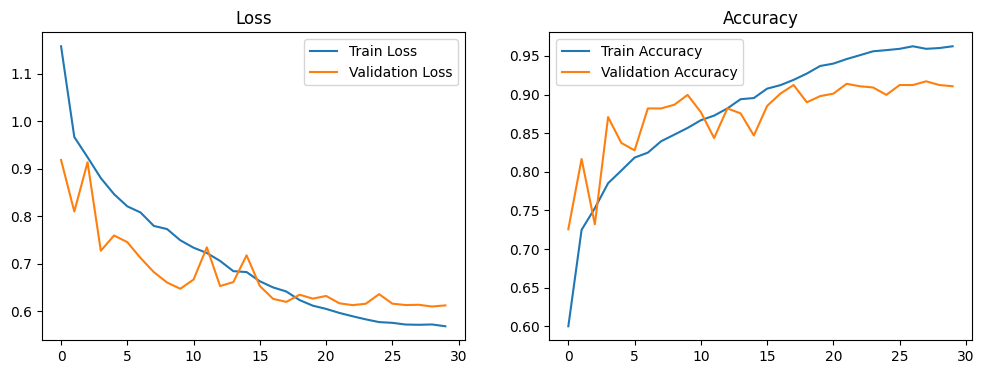

--- Training Meta Fold 4/5 ---
Original samples: 2508 -> Augmented total: 10032
Epoch 1/30 - loss: 1.2077 - acc: 0.5747 - val_loss: 0.9420 - val_acc: 0.7321
Epoch 2/30 - loss: 0.9888 - acc: 0.7076 - val_loss: 0.8821 - val_acc: 0.7735
Epoch 3/30 - loss: 0.9385 - acc: 0.7451 - val_loss: 0.8668 - val_acc: 0.8054
Epoch 4/30 - loss: 0.8965 - acc: 0.7744 - val_loss: 0.8049 - val_acc: 0.8262
Epoch 5/30 - loss: 0.8594 - acc: 0.7979 - val_loss: 0.8853 - val_acc: 0.7767
Epoch 6/30 - loss: 0.8395 - acc: 0.8118 - val_loss: 0.7843 - val_acc: 0.8246
Epoch 7/30 - loss: 0.8024 - acc: 0.8275 - val_loss: 0.7906 - val_acc: 0.8166
Epoch 8/30 - loss: 0.7809 - acc: 0.8372 - val_loss: 0.7593 - val_acc: 0.8230
Epoch 9/30 - loss: 0.7648 - acc: 0.8509 - val_loss: 0.7440 - val_acc: 0.8517
Epoch 10/30 - loss: 0.7513 - acc: 0.8572 - val_loss: 0.8056 - val_acc: 0.8102
Epoch 11/30 - loss: 0.7395 - acc: 0.8605 - val_loss: 0.6881 - val_acc: 0.8724
Epoch 12/30 - loss: 0.7231 - acc: 0.8710 - val_loss: 0.7188 - val_acc: 

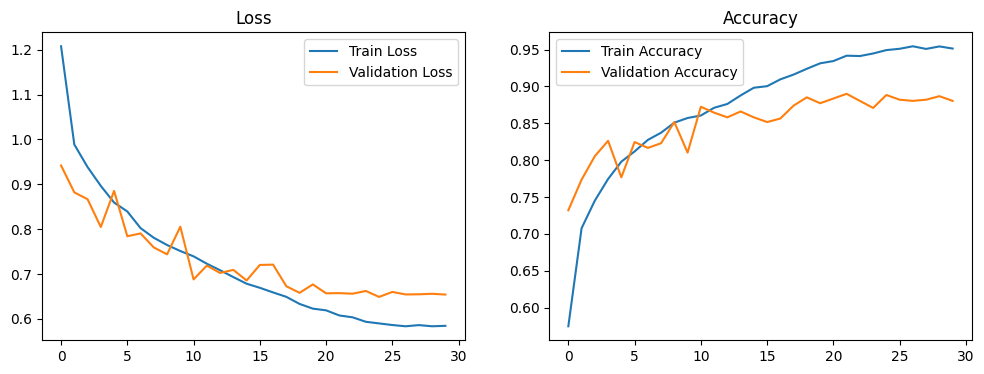

--- Training Meta Fold 5/5 ---
Original samples: 2508 -> Augmented total: 10032
Epoch 1/30 - loss: 1.2143 - acc: 0.5630 - val_loss: 0.9613 - val_acc: 0.7289
Epoch 2/30 - loss: 1.0159 - acc: 0.6866 - val_loss: 0.8994 - val_acc: 0.7751
Epoch 3/30 - loss: 0.9580 - acc: 0.7310 - val_loss: 0.8171 - val_acc: 0.8006
Epoch 4/30 - loss: 0.9021 - acc: 0.7669 - val_loss: 0.7774 - val_acc: 0.8166
Epoch 5/30 - loss: 0.8853 - acc: 0.7749 - val_loss: 0.7796 - val_acc: 0.8198
Epoch 6/30 - loss: 0.8545 - acc: 0.7898 - val_loss: 0.7444 - val_acc: 0.8325
Epoch 7/30 - loss: 0.8248 - acc: 0.8116 - val_loss: 0.7644 - val_acc: 0.8198
Epoch 8/30 - loss: 0.8073 - acc: 0.8192 - val_loss: 0.7215 - val_acc: 0.8469
Epoch 9/30 - loss: 0.7993 - acc: 0.8241 - val_loss: 0.7609 - val_acc: 0.8405
Epoch 10/30 - loss: 0.7935 - acc: 0.8256 - val_loss: 0.8003 - val_acc: 0.8086
Epoch 11/30 - loss: 0.7711 - acc: 0.8387 - val_loss: 0.7007 - val_acc: 0.8565
Epoch 12/30 - loss: 0.7602 - acc: 0.8464 - val_loss: 0.7375 - val_acc: 

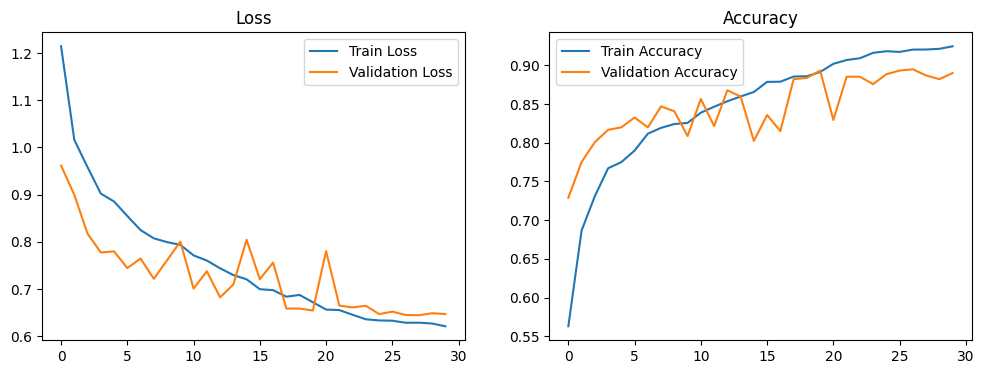

In [9]:
import numpy as np
import torch
from sklearn.model_selection import GroupKFold

meta_bagging_models = []
beatmap_ids_train = np.array(beatmap_ids_train)

# Initialize empty matrix for clean Out-Of-Fold CNN probability predictions
oof_cnn_predictions = np.zeros((len(X_train), num_classes), dtype=np.float32)

# Use GroupKFold so mapset difficulties stay grouped
gkf = GroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train_numerical, groups=beatmap_ids_train)):
    print(f"--- Training Meta Fold {fold + 1}/5 ---")

    # Split raw unaugmented fold data
    X_fold_train, y_fold_train = X_train[train_idx], y_train_numerical[train_idx]
    X_fold_val, y_fold_val = X_train[val_idx], y_train_numerical[val_idx]
    beatmap_ids_fold_train = beatmap_ids_train[train_idx]

    # Augment ONLY the training fold
    X_fold_train_aug, y_fold_train_aug, _ = augment_dataset(
        X_fold_train,
        y_fold_train,
        beatmap_ids_fold_train,
        augmentation_types={"horizontal", "vertical", "horizontal_vertical"}
    )

    # Convert validation fold to PyTorch Tensor (permuted to (B, C, L))
    X_fold_val = torch.as_tensor(X_fold_val, dtype=torch.float32).permute(0, 2, 1)
    y_fold_val = torch.as_tensor(y_fold_val, dtype=torch.long)

    X_fold_train_aug = X_fold_train_aug.permute(0, 2, 1)

    # Train CNN model for this fold
    model, history = train_and_evaluate(
        X_fold_train_aug,
        y_fold_train_aug,
        X_fold_val,
        y_fold_val,
        input_channels=X_fold_train_aug.shape[1],
        num_classes=num_classes,
        max_length=max_length,
        learning_rate=0.001,
        dropout_rate=0.5,
        l2_reg=0.001,
        batch_size=128,
        epochs=30,
        patience=8
    )
    plot_training_history(history)
    meta_bagging_models.append(model)

    # Generate Out-of-Fold predictions for the unaugmented validation set ONLY
    model.eval()
    with torch.no_grad():
        val_inputs = X_fold_val.to(device)
        logits = model(val_inputs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()

    # Store clean OOF predictions in the array
    oof_cnn_predictions[val_idx] = probs

In [10]:
import os

os.makedirs('models/bagged_models', exist_ok=True)

for i, model in enumerate(meta_bagging_models):
    torch.save(model.state_dict(), f'models/bagged_models/bagged_cnn_model_{i}.pth')

np.save("models/oof_cnn_predictions.npy", oof_cnn_predictions)
np.save("models/y_train_numerical.npy", y_train_numerical)
np.save("models/beatmap_ids_train.npy", np.array(beatmap_ids_train))

# XGBoost Meta Model

### Load Models and Data

In [11]:
from beatmap_classifier.classifier.cnn_model import CNNModel

model_kwargs = {
    "input_channels": 8,
    "num_classes": num_classes,
    "max_length": max_length,
    "dropout_rate": 0.5,
}

meta_bagging_models = load_pytorch_models(
    model_folder="models/bagged_models",
    model_class=CNNModel,
    model_kwargs=model_kwargs,
    device=device,
)

oof_cnn_predictions = np.load("models/oof_cnn_predictions.npy")
y_train_numerical = np.load("models/y_train_numerical.npy")

print(f"Loaded {len(meta_bagging_models)} CNN models")

Loaded 5 CNN models


### Test the bagging models

In [12]:
# Generate Test probabilities by averaging predictions across all fold models
X_test_tensor = torch.as_tensor(X_test, dtype=torch.float32).permute(0, 2, 1).to(device)
test_probs_list = []

for model in meta_bagging_models:
    model.eval()
    with torch.no_grad():
        logits = model(X_test_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        test_probs_list.append(probs)

bagged_test_predictions = np.mean(test_probs_list, axis=0)
bagged_test_predictions_numerical = np.argmax(bagged_test_predictions, axis=1)

score = accuracy_score(y_test_numerical, bagged_test_predictions_numerical)
cm = confusion_matrix(y_test_numerical, bagged_test_predictions_numerical)
report = classification_report(
    y_test_numerical,
    bagged_test_predictions_numerical,
    zero_division=0
)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {score}")

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97       194
           1       0.88      0.90      0.89       168
           2       0.94      0.90      0.92       192
           3       0.88      0.91      0.89       150
           4       0.75      0.74      0.74        80

    accuracy                           0.90       784
   macro avg       0.88      0.88      0.88       784
weighted avg       0.90      0.90      0.90       784

Confusion Matrix:
 [[189   1   2   1   1]
 [  0 152   2   0  14]
 [  4   2 172  12   2]
 [  1   5   5 136   3]
 [  2  12   2   5  59]]
Accuracy: 0.9030612244897959


### Setup

In [26]:
sql_feature_names = [
    "ar",
    "od",
    "circle_size",
    "star_rating",
    "bpm",
    "max_combo",
    "length_seconds",
    "object_count",
    "pp",
    "pp_aim",
    "pp_speed",
    "pp_acc"
]

movement_feature_names = [
    "slider_ratio",
    "slider_length_std",
    "speed_std",
    "speed_change_std",
    "speed_change_max",
    "angle_std",
    "angle_mean",
    "rhythm_variance",
    "distance_mean",
    "speed_change_95th",
    "angle_90th",
    "sharp_turn_ratio",
]

cnn_feature_names = [
    "CNN_NM1",
    "CNN_NM2",
    "CNN_NM3",
    "CNN_NM4",
    "CNN_NM5",
]

additional_feature_names = (
    sql_feature_names +
    movement_feature_names
)

In [27]:
configs = [
    dict(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=4,
        min_child_weight=1,
        subsample=0.85,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=1.0,
    ),
]

In [28]:
print(additional_feature_names)

['ar', 'od', 'circle_size', 'star_rating', 'bpm', 'max_combo', 'length_seconds', 'object_count', 'pp', 'pp_aim', 'pp_speed', 'pp_acc', 'slider_ratio', 'slider_length_std', 'speed_std', 'speed_change_std', 'speed_change_max', 'angle_std', 'angle_mean', 'rhythm_variance', 'distance_mean', 'speed_change_95th', 'angle_90th', 'sharp_turn_ratio']


In [29]:
selected_features = [
    feature
    for feature in additional_feature_names
    if feature not in ("slider_ratio")
]

additional_feature_groups = {
    "best": selected_features,
}

In [30]:
print(selected_features)

['ar', 'od', 'circle_size', 'star_rating', 'bpm', 'max_combo', 'length_seconds', 'object_count', 'pp', 'pp_aim', 'pp_speed', 'pp_acc', 'slider_length_std', 'speed_std', 'speed_change_std', 'speed_change_max', 'angle_std', 'angle_mean', 'rhythm_variance', 'distance_mean', 'speed_change_95th', 'angle_90th', 'sharp_turn_ratio']


In [31]:
from sklearn.metrics import f1_score

def get_feature_indices(feature_names, selected_features):
    missing = [
        name for name in selected_features
        if name not in feature_names
    ]

    if missing:
        raise ValueError(f"Features not found: {missing}")

    return [feature_names.index(name) for name in selected_features]

def make_xgb(params):
    return XGBClassifier(
        random_state=42,
        objective="multi:softprob",
        num_class=5,
        eval_metric="mlogloss",
        **params
    )

def evaluate_feature_set(
    selected_features,
    X_additional_train,
    X_additional_test,
    oof_cnn_predictions,
    bagged_test_predictions,
    y_train,
    y_test,
    params,
    compare_feature_groups,
    indices
):

    if not compare_feature_groups:
        indices = [
            additional_feature_names.index(name)
            for name in selected_features
        ]

    X_meta_train = np.hstack([
        oof_cnn_predictions,
        X_additional_train[:, indices],
    ])

    X_meta_test = np.hstack([
        bagged_test_predictions,
        X_additional_test[:, indices],
    ])

    model = make_xgb(params)
    model.fit(X_meta_train, y_train)

    pred = model.predict(X_meta_test)

    acc = accuracy_score(y_test, pred)
    macro_f1 = f1_score(y_test, pred, average="macro")
    cm = confusion_matrix(y_test, pred)

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "nm3_to_nm4": cm[2, 3],
        "nm4_to_nm3": cm[3, 2],
    }, model, pred

### Compare the XGBoost Classifiers within Feature Groups

In [32]:
from xgboost import XGBClassifier

feature_indices = {
    group_name: [
        additional_feature_names.index(feature)
        for feature in features
    ]
    for group_name, features in additional_feature_groups.items()
}

for group_name, indices in feature_indices.items():
    print("=" * 80)
    print(f"FEATURE GROUP: {group_name}")
    print("=" * 80)

    for i, params in enumerate(configs):

        results, model, pred = evaluate_feature_set(
            selected_features=None,
            X_additional_train=X_additional_train,
            X_additional_test=X_additional_test,
            oof_cnn_predictions=oof_cnn_predictions,
            bagged_test_predictions=bagged_test_predictions,
            y_train=y_train_numerical,
            y_test=y_test_numerical,
            params=configs[0],
            compare_feature_groups=True,
            indices=indices
        )

        report = classification_report(y_test_numerical, pred, output_dict=True, zero_division=0)
        print(f"Config {i}: accuracy={results["accuracy"] * 100:.2f}% | macro_f1={results["macro_f1"]:.4f}")

FEATURE GROUP: best
Config 0: accuracy=94.13% | macro_f1=0.9335


### Compare the XGBoost Classifiers by removing single features

In [33]:
import pandas as pd

all_features = additional_feature_groups["best"]

baseline, meta_model, y_pred_meta = evaluate_feature_set(
    selected_features=all_features,
    X_additional_train=X_additional_train,
    X_additional_test=X_additional_test,
    oof_cnn_predictions=oof_cnn_predictions,
    bagged_test_predictions=bagged_test_predictions,
    y_train=y_train_numerical,
    y_test=y_test_numerical,
    params=configs[0],
    compare_feature_groups=False,
    indices=None
)

with open("models/meta_model.pkl", "wb") as f:
    pickle.dump(meta_model, f)

print("Baseline:")
print(baseline)

baseline_acc = baseline["accuracy"]
baseline_f1 = baseline["macro_f1"]

array_results = []

for removed_feature in all_features:

    remaining_features = [
        feature
        for feature in all_features
        if feature != removed_feature
    ]

    results, _, _ = evaluate_feature_set(
        selected_features=remaining_features,
        X_additional_train=X_additional_train,
        X_additional_test=X_additional_test,
        oof_cnn_predictions=oof_cnn_predictions,
        bagged_test_predictions=bagged_test_predictions,
        y_train=y_train_numerical,
        y_test=y_test_numerical,
        params=configs[0],
        compare_feature_groups=False,
        indices=None
    )

    dict_results = {
        "removed": removed_feature,
        "accuracy": results["accuracy"],
        "macro_f1": results["macro_f1"],
        "acc_delta": results["accuracy"] - baseline_acc,
        "f1_delta": results["macro_f1"] - baseline_f1,
        "nm3_to_nm4": results["nm3_to_nm4"],
        "nm4_to_nm3": results["nm4_to_nm3"]
    }

    array_results.append(dict_results)

results_df = pd.DataFrame(array_results)

results_df = results_df.sort_values(
    "acc_delta",
    ascending=False
)

print(results_df.to_string(index=False))

Baseline:
{'accuracy': 0.9413265306122449, 'macro_f1': 0.9334992724524271, 'nm3_to_nm4': np.int64(7), 'nm4_to_nm3': np.int64(3)}
          removed  accuracy  macro_f1  acc_delta  f1_delta  nm3_to_nm4  nm4_to_nm3
      star_rating  0.940051  0.931531  -0.001276 -0.001968           6           4
 sharp_turn_ratio  0.940051  0.931868  -0.001276 -0.001631           6           4
      circle_size  0.938776  0.930315  -0.002551 -0.003184           6           5
           pp_acc  0.938776  0.930355  -0.002551 -0.003145           7           4
       angle_90th  0.938776  0.930912  -0.002551 -0.002587           7           4
               od  0.938776  0.930377  -0.002551 -0.003122           6           4
   length_seconds  0.937500  0.928565  -0.003827 -0.004935           6           4
       angle_mean  0.937500  0.928432  -0.003827 -0.005067           6           4
        angle_std  0.937500  0.928427  -0.003827 -0.005072           7           3
           pp_aim  0.937500  0.928410  -0

### Testing our best (aka baseline) XGBoost Model

In [34]:
indices = [
    additional_feature_names.index(name)
    for name in selected_features
]

X_meta_train = np.hstack([
    oof_cnn_predictions,
    X_additional_train[:, indices],
])

X_meta_test = np.hstack([
    bagged_test_predictions,
    X_additional_test[:, indices],
])

test_acc = accuracy_score(y_test_numerical, y_pred_meta)

print(f"--- XGBoost Meta-Model Performance ---")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test_numerical, y_pred_meta, target_names=["NM1", "NM2", "NM3", "NM4", "NM5"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test_numerical, y_pred_meta))

--- XGBoost Meta-Model Performance ---
Final Test Accuracy: 94.13%

Classification Report:
              precision    recall  f1-score   support

         NM1       0.97      0.97      0.97       194
         NM2       0.93      0.93      0.93       168
         NM3       0.96      0.94      0.95       192
         NM4       0.93      0.93      0.93       150
         NM5       0.86      0.90      0.88        80

    accuracy                           0.94       784
   macro avg       0.93      0.94      0.93       784
weighted avg       0.94      0.94      0.94       784

Confusion Matrix:
[[189   0   2   2   1]
 [  0 157   1   1   9]
 [  3   1 180   7   1]
 [  1   5   3 140   1]
 [  2   5   1   0  72]]


# Analysis

In [35]:
importance = meta_model.feature_importances_
meta_model_features = cnn_feature_names + selected_features

for name, value in sorted(
    zip(meta_model_features, importance),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{name:30s} {value:.4f}")

CNN_NM1                        0.1761
CNN_NM2                        0.1635
CNN_NM3                        0.1383
CNN_NM4                        0.1377
CNN_NM5                        0.1216
sharp_turn_ratio               0.0371
bpm                            0.0368
distance_mean                  0.0305
slider_length_std              0.0192
angle_mean                     0.0165
pp_speed                       0.0128
angle_std                      0.0093
od                             0.0090
pp                             0.0088
object_count                   0.0086
pp_acc                         0.0085
star_rating                    0.0081
pp_aim                         0.0080
angle_90th                     0.0079
ar                             0.0077
speed_std                      0.0076
length_seconds                 0.0073
max_combo                      0.0066
rhythm_variance                0.0065
circle_size                    0.0061
speed_change_std               0.0000
speed_change

In [36]:
feature_names = [
    "AR",
    "OD",
    "Circle Size",
    "Star Rating",
    "BPM",
    "Max Combo",
    "Length (s)",
    "Object Count",
]

print("\nRaw Additional feature ranges:")
print("-" * 70)

for i, name in enumerate(feature_names):
    values = raw_additional_features_array[:, i]

    print(
        f"{name:15s} "
        f"min={np.min(values):8.2f}  "
        f"max={np.max(values):8.2f}  "
        f"mean={np.mean(values):8.2f}  "
        f"median={np.median(values):8.2f}"
    )

print("\nRaw Additional feature percentiles:")
print("-" * 90)

for i, name in enumerate(feature_names):
    values = raw_additional_features_array[:, i]

    p = np.percentile(values, [1, 5, 25, 50, 75, 95, 99])

    print(
        f"{name:15s} "
        f"1%={p[0]:8.2f}  "
        f"5%={p[1]:8.2f}  "
        f"25%={p[2]:8.2f}  "
        f"50%={p[3]:8.2f}  "
        f"75%={p[4]:8.2f}  "
        f"95%={p[5]:8.2f}  "
        f"99%={p[6]:8.2f}"
    )


Raw Additional feature ranges:
----------------------------------------------------------------------
AR              min=    6.80  max=   10.00  mean=    9.50  median=    9.50
OD              min=    5.00  max=   10.00  mean=    8.86  median=    9.00
Circle Size     min=    2.00  max=    7.00  mean=    4.01  median=    4.00
Star Rating     min=    3.12  max=   19.09  mean=    6.79  median=    6.73
BPM             min=   50.00  max=  363.86  mean=  184.70  median=  185.00
Max Combo       min=  252.00  max=10215.00  mean= 1526.44  median= 1449.00
Length (s)      min=   18.29  max= 1645.53  mean=  192.85  median=  194.45
Object Count    min=  156.00  max= 6310.00  mean= 1085.57  median= 1022.00

Raw Additional feature percentiles:
------------------------------------------------------------------------------------------
AR              1%=    9.00  5%=    9.20  25%=    9.40  50%=    9.50  75%=    9.60  95%=    9.80  99%=   10.00
OD              1%=    7.50  5%=    8.00  25%=    8.50  50

In [37]:
bpm = raw_additional_features_array[:, 4]
for threshold in [300, 400, 500, 600, 800, 1000]:
    count = np.sum(bpm > threshold)

    print(
        f"bpm > {threshold:4d}: "
        f"{count:6d} "
        f"({count / len(bpm) * 100:.3f}%)"
    )

bpm >  300:     10 (0.255%)
bpm >  400:      0 (0.000%)
bpm >  500:      0 (0.000%)
bpm >  600:      0 (0.000%)
bpm >  800:      0 (0.000%)
bpm > 1000:      0 (0.000%)


In [38]:
sequence_lengths = np.array([len(seq) for seq in X])

print("Number of beatmaps:", len(sequence_lengths))
print("Min:", sequence_lengths.min())
print("Median:", np.median(sequence_lengths))
print("Mean:", sequence_lengths.mean())
print("75th:", np.percentile(sequence_lengths, 75))
print("90th:", np.percentile(sequence_lengths, 90))
print("95th:", np.percentile(sequence_lengths, 95))
print("99th:", np.percentile(sequence_lengths, 99))
print("Max:", sequence_lengths.max())

Number of beatmaps: 3919
Min: 155
Median: 1021.0
Mean: 1084.5743812196988
75th: 1246.0
90th: 1577.2000000000003
95th: 1874.0
99th: 2533.100000000001
Max: 6309
